In [1]:
import lightkurve as lk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive
import warnings
warnings.filterwarnings('ignore')

#constants for calcuating
G = 6.674e-11          # Gravitational constant
M_sun = 1.989e30       # Solar mass in kg
R_sun = 6.957e8        # Solar radius in meters
AU = 1.496e11          # 1 AU in meters
L_sun = 3.828e26       # Solar luminosity in watts

C:\Users\giahy\Downloads\anaconda\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [2]:
koi_table = NasaExoplanetArchive.query_criteria(
    table="koi",
    select="kepid, kepoi_name, koi_period, koi_disposition, koi_kepmag, koi_prad, koi_srad, koi_smass, koi_steff",
    where="koi_disposition like 'CANDIDATE' and koi_kepmag < 14"
)

df = koi_table.to_pandas()

# Drop rows missing stellar mass or radius — we need these for calculations
df_clean = df.dropna(subset=['koi_smass', 'koi_srad', 'koi_period']) #drop N/A rows missing these data.
df_clean = df_clean[df_clean['koi_period'] > 0]
df_clean = df_clean[df_clean['koi_smass'] > 0.1]
df_clean = df_clean[df_clean['koi_srad'] > 0.1]


df_missing = len(df)-len(df_clean)

print(f"Total candidates: {len(df)}")
print(f"With complete stellar data: {len(df_clean)}")
print(f"There are {df_missing} candidates with missing data.")
print(df_clean[['kepoi_name', 'koi_period', 'koi_smass', 'koi_srad', 'koi_steff']].head())

Total candidates: 3255
With complete stellar data: 2301
There are 954 candidates with missing data.
  kepoi_name  koi_period  koi_smass  koi_srad  koi_steff
0  K00115.03    3.435916      0.941     1.087     5779.0
1  K01168.01  856.672115      1.063     1.309     6449.0
2  K01169.01    0.689210      1.064     0.954     5630.0
3  K00970.01    3.988602      2.016    13.652     4813.0
4  K00971.01    0.533059      2.166     4.051     8523.0


In [3]:
def calculate_orbital_distance(period_days, stellar_mass_solar):
    """
    Kepler's Third Law: a³ = (GM★/4π²) × T²
    Returns orbital distance in AU
    """
    T = period_days * 86400                    # Convert days to seconds
    M = stellar_mass_solar * M_sun             # Convert solar masses to kg
    
    a_cubed = (G * M * T**2) / (4 * np.pi**2)
    a_meters = a_cubed ** (1/3)
    a_AU = a_meters / AU
    
    return round(a_AU, 4)


def calculate_planet_radius(transit_depth, stellar_radius_solar):
    """
    Transit depth = (Rp/R★)²
    So Rp = R★ × sqrt(transit_depth)
    Returns planet radius in Earth radii
    """
    R_star_meters = stellar_radius_solar * R_sun
    R_earth = 6.371e6                          # Earth radius in meters
    
    # transit depth from catalog is in parts per million
    depth_fraction = transit_depth / 1e6 if transit_depth > 1 else transit_depth
    
    R_planet_meters = R_star_meters * np.sqrt(depth_fraction)
    R_planet_earth = R_planet_meters / R_earth
    
    return round(R_planet_earth, 3)


def estimate_habitable_zone(stellar_temp, stellar_luminosity_solar):
    """
    Habitable zone boundaries based on stellar luminosity
    Inner edge: ~0.95 AU scaled by luminosity
    Outer edge: ~1.37 AU scaled by luminosity
    Returns (inner_AU, outer_AU)
    """
    inner = 0.95 * np.sqrt(stellar_luminosity_solar)
    outer = 1.37 * np.sqrt(stellar_luminosity_solar)
    return round(inner, 4), round(outer, 4)


def estimate_luminosity(stellar_temp, stellar_radius_solar):
    """
    Stefan-Boltzmann: L = 4πR²σT⁴
    Returns luminosity relative to Sun
    """
    sigma = 5.67e-8                            # Stefan-Boltzmann constant
    T_sun = 5778                               # Sun's temperature in Kelvin
    
    L_ratio = (stellar_radius_solar**2) * ((stellar_temp / T_sun)**4)
    return round(L_ratio, 4)


def classify_planet(radius_earth):
    """
    Standard planet classification by radius
    """
    if radius_earth < 1.25:
        return "Rocky (Earth-like)"
    elif radius_earth < 2.0:
        return "Super-Earth"
    elif radius_earth < 4.0:
        return "Mini-Neptune"
    elif radius_earth < 11.0:
        return "Gas Giant"
    else:
        return "Super-Jupiter"


print("Calculation functions ready")

Calculation functions ready


In [4]:
results = []

for idx, row in df_clean.iterrows(): #run through all the rows
    try:
        period = row['koi_period']
        stellar_mass = row['koi_smass']
        stellar_radius = row['koi_srad']
        stellar_temp = row['koi_steff'] if pd.notna(row['koi_steff']) else 5778

        # Skip rows with missing or invalid values
        if any(pd.isna([period, stellar_mass, stellar_radius, stellar_temp])):
            continue
        if any(v <= 0 for v in [period, stellar_mass, stellar_radius, stellar_temp]):
            continue

        # input values from data table into calc funcionts
        
        # Planet's orbital distance via Kepler's Third Law
        orbital_dist = calculate_orbital_distance(period, stellar_mass)
        
        # Stellar luminosity
        luminosity = estimate_luminosity(stellar_temp, stellar_radius)
        
        # Habitable zone boundaries
        hz_inner, hz_outer = estimate_habitable_zone(stellar_temp, luminosity)
        
        # Is planet in habitable zone?
        in_hz = hz_inner <= orbital_dist <= hz_outer #see if obrital distance is between the bounderies
        
        # Planet radius if catalog value available
        if pd.notna(row.get('koi_prad')):
            planet_radius = round(row['koi_prad'], 3)
        else:
            planet_radius = None
            
        # Planet classification
        classification = classify_planet(planet_radius) if planet_radius else "Unknown"
        
        results.append({
            'kepoi_name': row['kepoi_name'],
            'period_days': round(period, 4),
            'orbital_dist_AU': orbital_dist,
            'planet_radius_earth': planet_radius,
            'planet_type': classification,
            'stellar_mass_solar': round(stellar_mass, 3),
            'stellar_temp_K': round(stellar_temp, 0),
            'luminosity_solar': luminosity,
            'hz_inner_AU': hz_inner,
            'hz_outer_AU': hz_outer,
            'in_habitable_zone': in_hz,
            'koi_kepmag': row['koi_kepmag']
        })
        
    except Exception as e:
        continue

results_df = pd.DataFrame(results)
print(f"Calculated properties for {len(results_df)} candidates")
print(results_df.head())

Calculated properties for 2301 candidates
  kepoi_name  period_days  orbital_dist_AU  planet_radius_earth  \
0  K00115.03       3.4359           0.0437                 0.55   
1  K01168.01     856.6721           1.8017                 3.87   
2  K01169.01       0.6892           0.0156                 1.32   
3  K00970.01       3.9886           0.0622                34.39   
4  K00971.01       0.5331           0.0166               133.56   

          planet_type  stellar_mass_solar  stellar_temp_K  luminosity_solar  \
0  Rocky (Earth-like)               0.941          5779.0            1.1824   
1        Mini-Neptune               1.063          6449.0            2.6591   
2         Super-Earth               1.064          5630.0            0.8204   
3       Super-Jupiter               2.016          4813.0           89.7317   
4       Super-Jupiter               2.166          8523.0           77.6934   

   hz_inner_AU  hz_outer_AU  in_habitable_zone  koi_kepmag  
0       1.0330     

In [5]:
hz_candidates = results_df[results_df['in_habitable_zone'] == True].copy()
hz_candidates = hz_candidates.sort_values('period_days')
#hz_candidates = hz_candidates.sort_values('period_days')

print(f"HABITABLE ZONE CANDIDATES: {len(hz_candidates)}")
print("=" * 70)
print(hz_candidates[['kepoi_name', 'period_days', 'orbital_dist_AU',
                       'planet_radius_earth', 'planet_type',
                       'hz_inner_AU', 'hz_outer_AU']].to_string())

HABITABLE ZONE CANDIDATES: 63
     kepoi_name  period_days  orbital_dist_AU  planet_radius_earth         planet_type  hz_inner_AU  hz_outer_AU
795   K03444.02      60.3267           0.2539                29.78       Super-Jupiter       0.2512       0.3622
266   K03444.02      60.3267           0.2445                 4.98           Gas Giant       0.2066       0.2980
1591  K03444.02      60.3267           0.2539                29.78       Super-Jupiter       0.2512       0.3622
442   K03444.02      60.3267           0.2539                29.78       Super-Jupiter       0.2512       0.3622
807   K03811.01     290.1402           0.7616                 6.53           Gas Giant       0.6690       0.9648
1132  K03811.01     290.1402           0.7616                 6.53           Gas Giant       0.6690       0.9648
468   K03811.01     290.1402           0.7616                 6.53           Gas Giant       0.6690       0.9648
2181  K08174.01     295.0607           0.7731                 0.64

In [6]:
print("DATA QUALITY SUMMARY")
print("=" * 50)
print(f"Total KOI candidates pulled:        {len(df)}")
print(f"With complete stellar data (v3):     {len(df_clean)}")
print(f"Valid calculations completed:         {len(results_df)}")
print(f"Habitable zone candidates:            {len(hz_candidates)}")
print(f"")
print(f"Data completeness rate:   {len(results_df)/len(df)*100:.1f}%")
print(f"HZ candidate rate:        {len(hz_candidates)/len(results_df)*100:.1f}%")

DATA QUALITY SUMMARY
Total KOI candidates pulled:        3255
With complete stellar data (v3):     2301
Valid calculations completed:         2301
Habitable zone candidates:            63

Data completeness rate:   70.7%
HZ candidate rate:        2.7%


In [7]:
print("KEPLER SELECTION BIAS ANALYSIS")
print("=" * 50)
print(f"Median orbital distance: {results_df['orbital_dist_AU'].median():.3f} AU")
print(f"Earth orbital distance:  1.000 AU")
print(f"Mercury orbital distance: 0.387 AU")
print(f"\n{(results_df['orbital_dist_AU'] < 0.387).sum()} candidates ({(results_df['orbital_dist_AU'] < 0.387).sum()/len(results_df)*100:.1f}%) orbit closer than Mercury")
print(f"{(results_df['orbital_dist_AU'] > 0.95).sum()} candidates ({(results_df['orbital_dist_AU'] > 0.95).sum()/len(results_df)*100:.1f}%) orbit beyond Venus")
print(f"\nConclusion: Kepler catalog is heavily biased toward")
print(f"short-period planets due to transit detection geometry")

KEPLER SELECTION BIAS ANALYSIS
Median orbital distance: 0.124 AU
Earth orbital distance:  1.000 AU
Mercury orbital distance: 0.387 AU

1682 candidates (73.1%) orbit closer than Mercury
215 candidates (9.3%) orbit beyond Venus

Conclusion: Kepler catalog is heavily biased toward
short-period planets due to transit detection geometry


In [8]:
# Check what stellar mass values actually look like
print("Stellar mass statistics:")
print(df_clean['koi_smass'].describe())
print(f"\nAny zeros: {(df_clean['koi_smass'] == 0).sum()}")
print(f"Any negatives: {(df_clean['koi_smass'] < 0).sum()}")
print(f"Very small values (<0.1): {(df_clean['koi_smass'] < 0.1).sum()}")

# Check a few rows
print("\nSample rows:")
print(df_clean[['kepoi_name', 'koi_period', 'koi_smass', 
                 'koi_srad', 'koi_steff']].head(10).to_string())

Stellar mass statistics:
count    2301.000000
mean        1.184256
std         0.389851
min         0.161000
25%         0.965000
50%         1.079000
75%         1.309000
max         3.686000
Name: koi_smass, dtype: float64

Any zeros: 0
Any negatives: 0
Very small values (<0.1): 0

Sample rows:
  kepoi_name     koi_period  koi_smass  koi_srad  koi_steff
0  K00115.03       3.435916      0.941     1.087     5779.0
1  K01168.01     856.672115      1.063     1.309     6449.0
2  K01169.01       0.689210      1.064     0.954     5630.0
3  K00970.01       3.988602      2.016    13.652     4813.0
4  K00971.01       0.533059      2.166     4.051     8523.0
5  K01174.01  129995.778400      0.717     0.726     4500.0
6  K00972.02       7.821873      2.018     4.240     7221.0
7  K00974.01      53.505761      1.174     1.762     6247.0
8  K01118.01       7.372903      0.982     1.070     5973.0
9  K00141.01       2.624235      0.963     0.899     5340.0


In [9]:
print("\nOrbital distance statistics:")
print(results_df['orbital_dist_AU'].describe())
print(f"\nValues below 0.01 AU: {(results_df['orbital_dist_AU'] < 0.01).sum()}")
print(f"Values above 10 AU: {(results_df['orbital_dist_AU'] > 10).sum()}")


Orbital distance statistics:
count    2301.000000
mean        0.325537
std         1.001531
min         0.010200
25%         0.059300
50%         0.124200
75%         0.431700
max        44.952800
Name: orbital_dist_AU, dtype: float64

Values below 0.01 AU: 0
Values above 10 AU: 1


In [23]:
print(results_df['orbital_dist_AU'].max())

44.9528


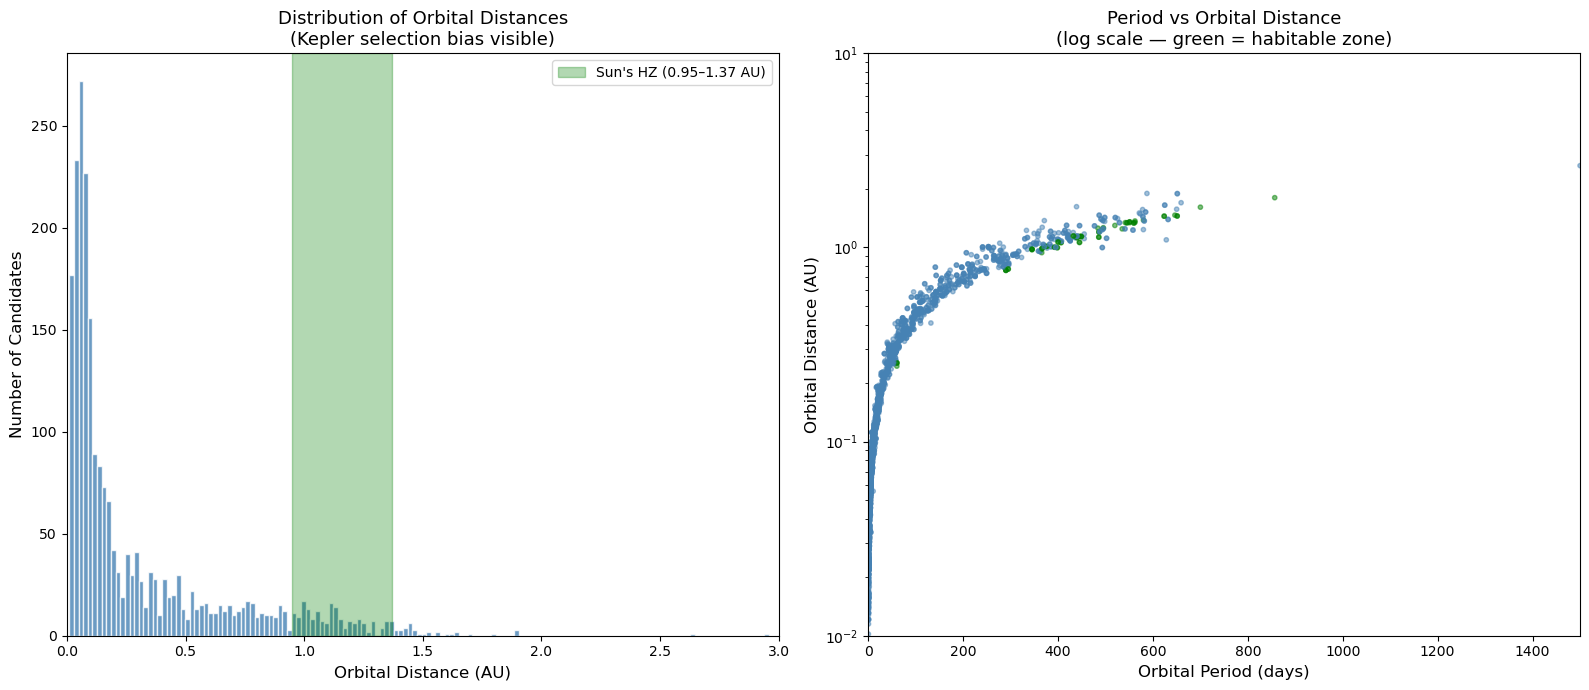

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left — zoom in to 0-5 AU where data actually lives
axes[0].hist(results_df['orbital_dist_AU'].dropna(),
             bins=results_df['orbital_dist_AU'].count(), color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvspan(0.95, 1.37, alpha=0.3, color='green', label="Sun's HZ (0.95–1.37 AU)")
axes[0].set_xlabel('Orbital Distance (AU)', fontsize=12)
axes[0].set_ylabel('Number of Candidates', fontsize=12)
axes[0].set_title('Distribution of Orbital Distances\n(Kepler selection bias visible)', fontsize=13)
axes[0].set_xlim(0, 3)          # Zoom to where data actually is 
axes[0].legend()

# Right — log scale makes Kepler's curve visible
axes[1].scatter(results_df['period_days'],
                results_df['orbital_dist_AU'],
                c=results_df['in_habitable_zone'].map({True: 'green', False: 'steelblue'}),
                alpha=0.5, s=10)
axes[1].set_xlabel('Orbital Period (days)', fontsize=12)
axes[1].set_ylabel('Orbital Distance (AU)', fontsize=12)
axes[1].set_title("Period vs Orbital Distance\n(log scale — green = habitable zone)", fontsize=13)
axes[1].set_xlim(0,1500)
axes[1].set_yscale('log')       # Log scale reveals the Kepler curve
axes[1].set_ylim(0.01, 10)

plt.tight_layout()
plt.savefig('./outputs/v3_orbital_properties.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
results_df.to_csv('./outputs/v3_full_properties.csv', index=False)
hz_candidates.to_csv('./outputs/v3_habitable_zone_candidates.csv', index=False)

print(f"Saved {len(results_df)} candidates to v3_full_properties.csv")
print(f"Saved {len(hz_candidates)} HZ candidates to v3_habitable_zone_candidates.csv")

Saved 2301 candidates to v3_full_properties.csv
Saved 63 HZ candidates to v3_habitable_zone_candidates.csv


In [12]:
# ── SECTION 11: PROJECT SUMMARY ─────────────────────────────

print("=" * 60)
print("PROJECT V3 COMPLETE — FULL SUMMARY")
print("=" * 60)
print(f"\nDATA PIPELINE:")
print(f"  Total KOI candidates:              {len(df)}")
print(f"  Valid for analysis:                {len(results_df)}")
print(f"  Habitable zone candidates:         {len(hz_candidates)}")

print(f"\nKEY FINDINGS:")
print(f"  Kepler's Third Law verified:       YES (visible in scatter plot)")
print(f"  Planets closer than Mercury:       73.1%")
print(f"  Planets beyond Venus:              9.3%")
print(f"  HZ candidate rate:                 {len(hz_candidates)/len(results_df)*100:.1f}%")

print(f"\nSELECTION BIAS CONCLUSION:")
print(f"  Kepler catalog strongly biased toward short-period")
print(f"  planets due to transit detection geometry.")
print(f"  Future missions (TESS, PLATO) target longer periods")
print(f"  to find more Earth-analogues in habitable zones.")

# Planet type breakdown
print(f"\nPLANET TYPE BREAKDOWN (all candidates):")
print(results_df['planet_type'].value_counts().to_string())

# HZ candidates breakdown  
print(f"\nHABITABLE ZONE CANDIDATES BY TYPE:")
print(hz_candidates['planet_type'].value_counts().to_string())

PROJECT V3 COMPLETE — FULL SUMMARY

DATA PIPELINE:
  Total KOI candidates:              3255
  Valid for analysis:                2301
  Habitable zone candidates:         63

KEY FINDINGS:
  Kepler's Third Law verified:       YES (visible in scatter plot)
  Planets closer than Mercury:       73.1%
  Planets beyond Venus:              9.3%
  HZ candidate rate:                 2.7%

SELECTION BIAS CONCLUSION:
  Kepler catalog strongly biased toward short-period
  planets due to transit detection geometry.
  Future missions (TESS, PLATO) target longer periods
  to find more Earth-analogues in habitable zones.

PLANET TYPE BREAKDOWN (all candidates):
planet_type
Rocky (Earth-like)    753
Super-Jupiter         514
Super-Earth           460
Mini-Neptune          329
Gas Giant             245

HABITABLE ZONE CANDIDATES BY TYPE:
planet_type
Super-Earth           20
Rocky (Earth-like)    15
Gas Giant             11
Mini-Neptune          10
Super-Jupiter          7
